In [21]:
include("QFactorOOO.jl")
using Plots
using ProgressMeter

In [4]:
ω = 0.1
rmin = 6.0
rmax = 10^4

sol1 = linear_sol(2, ω, "odd", rmin, rmax);
sol2 = linear_sol(3, ω, "odd", rmin, rmax);

In [26]:
aux = collect(-6.0:0.002:4.0)
r_vals = @. 2.0 + 10^aux
reg_src_a = zeros(length(r_vals))
reg_src_b = zeros(length(r_vals))

for (i,r) in enumerate(r_vals)
    reg_src_a[i] = abs.(SOOO(sol1, sol2, ω, ω, 2, 3, 2, 1, -1, r))
    reg_src_b[i] = abs.(SOOO_bruno(sol1, sol2, ω, ω, 2, 3, 2, 1, -1, r))
end

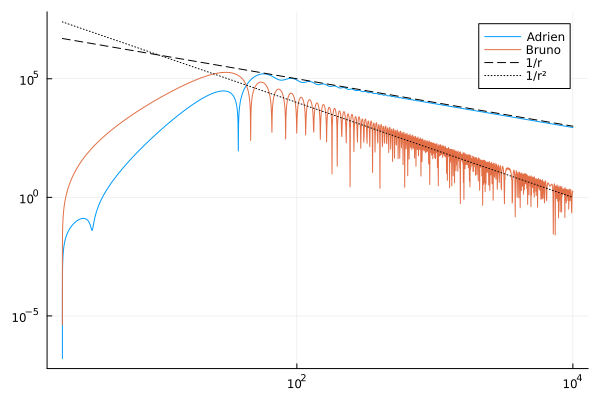

In [27]:
plot(r_vals, reg_src_a, xscale=:log10, yscale=:log10, label="Adrien")
plot!(r_vals, reg_src_b, xscale=:log10, yscale=:log10, label="Bruno")
plot!(r_vals, 1e7 ./r_vals, label="1/r", ls=:dash, color=:black)
plot!(r_vals, 1e8 ./r_vals.^2, label="1/r²", ls=:dot, color=:black)

In [28]:
w=0.1
Λ = 4.0
qf = abs(qfactor_ooo(w, 2, 3, 2, 1, -1, rmin=Λ+1, rmax=10^(Λ-1)/w, source="adrien"))

0.017372394047946913

In [29]:
qf_b = abs(qfactor_ooo(w, 2, 3, 2, 1, -1, rmin=Λ+1, rmax=10^(Λ-1)/w, source="bruno"))


0.017177990446849437

In [30]:
l_vals = collect(3.0:0.25:5.0)
ω_vals = collect(0.1:0.3:0.4)
q_vals = zeros((length(ω_vals), length(l_vals)))
qb_vals = zeros((length(ω_vals), length(l_vals)))

@showprogress for (i,Λ) in enumerate(l_vals)
    for (j,w) in enumerate(ω_vals)
        qf = abs(qfactor_ooo(w, 2, 3, 2, 1, -1, rmin=Λ+1, rmax=10^(Λ-1)/w, solver_lin="verne", solver_scd="verne"))
        q_vals[j,i]=qf
        qf_b = abs(qfactor_ooo(w, 2, 3, 2, 1, -1, rmin=Λ+1, rmax=10^(Λ-1)/w, solver_lin="verne", solver_scd="verne", source="bruno"))
        qb_vals[j,i]=qf_b
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:19
Progress: 100%|█████████████████████████████████████████| Time: 0:00:19


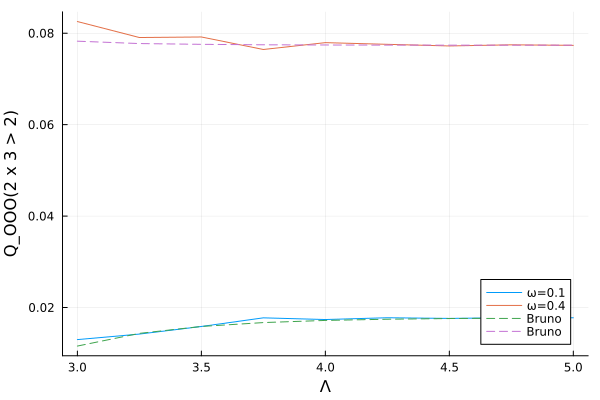

In [33]:
plot(l_vals, q_vals[1,:], label="ω=$(ω_vals[1])")
plot!(l_vals, q_vals[2,:], label="ω=$(ω_vals[2])")
plot!(l_vals, qb_vals[1,:], label="Bruno", ls=:dash)
plot!(l_vals, qb_vals[2,:], label="Bruno", ls=:dash)

xlabel!("Λ")
ylabel!("Q_OOO(2 x 3 > 2)")


The following takes about 7' to run

In [61]:
ω_vals = collect(0.05:0.02:0.6)
q_vals = zeros(length(ω_vals))

@showprogress for (j,w) in enumerate(ω_vals)
    if w < 0.3
        Λ = 4.0
    elseif w < 0.6
        Λ = 5.0
    else 
        Λ = 6.0
    end
    q_vals[j] = abs(qfactor_ooo(w, 2, 3, 2, 1, -1, rmin=Λ+1, rmax=10^(Λ-1)/w, solver_lin="verne", solver_scd="verne"))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:06:55


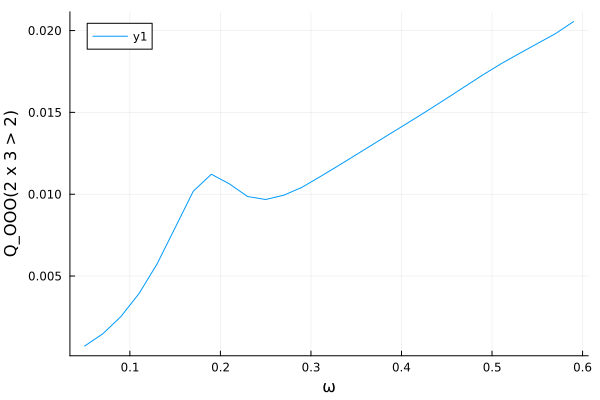

In [62]:
l_1=2
l_2=3
ll=2
q_h = @. 2*q_vals * sqrt(ll*(ll+1)*(ll+2)*(ll-1) / (l_1*(l_1+1)*(l_1+2)*(l_1-1) * l_2*(l_2+1)*(l_2+2)*(l_2-1))) 

plot(ω_vals, q_h)
xlabel!("ω")
ylabel!("Q_OOO(2 x 3 > 2)")

In [65]:
open("../data/q_ooo_adrien.dat", "w") do io 
    println(io,"w q")
    for (w,q) in zip(ω_vals, q_h)
        println(io,"$(w) $(q)")
    end
end

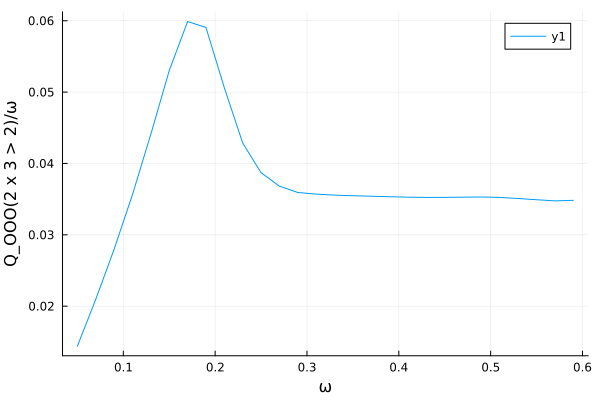

In [66]:
l_1=2
l_2=3
ll=2
q_h = @. 2*q_vals * sqrt(ll*(ll+1)*(ll+2)*(ll-1) / (l_1*(l_1+1)*(l_1+2)*(l_1-1) * l_2*(l_2+1)*(l_2+2)*(l_2-1)))  / ω_vals

plot(ω_vals, q_h)
xlabel!("ω")
ylabel!("Q_OOO(2 x 3 > 2)/ω")